In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import pickle

In [124]:
df = pd.read_csv('/workspaces/Antonio27M-machine-learning/data/raw/internal-link-medic.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Predecir el coste del seguro médico de una persona

La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

- age. Edad del beneficiario principal (numérico)
- sex. Género del beneficiario principal (categórico)
- bmi. índice de masa corporal (numérico)
- children. Número de niños/dependientes cubiertos por un seguro médico (numérico)
- smoker. ¿Es fumador? (categórico)
- region. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
- charges. Prima del seguro médico (numérico) TARGET

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [126]:
df.drop_duplicates(inplace=True)

### Factorize. 

In [127]:
df_factorize = df.copy()

In [128]:
df_factorize['number_region'] = pd.factorize(df['region'])[0]
df_factorize['number_smoker'] = pd.factorize(df['smoker'])[0]
df_factorize['number_sex'] = pd.factorize(df['sex'])[0]
df_numerico = df_factorize.select_dtypes(include=['number'])

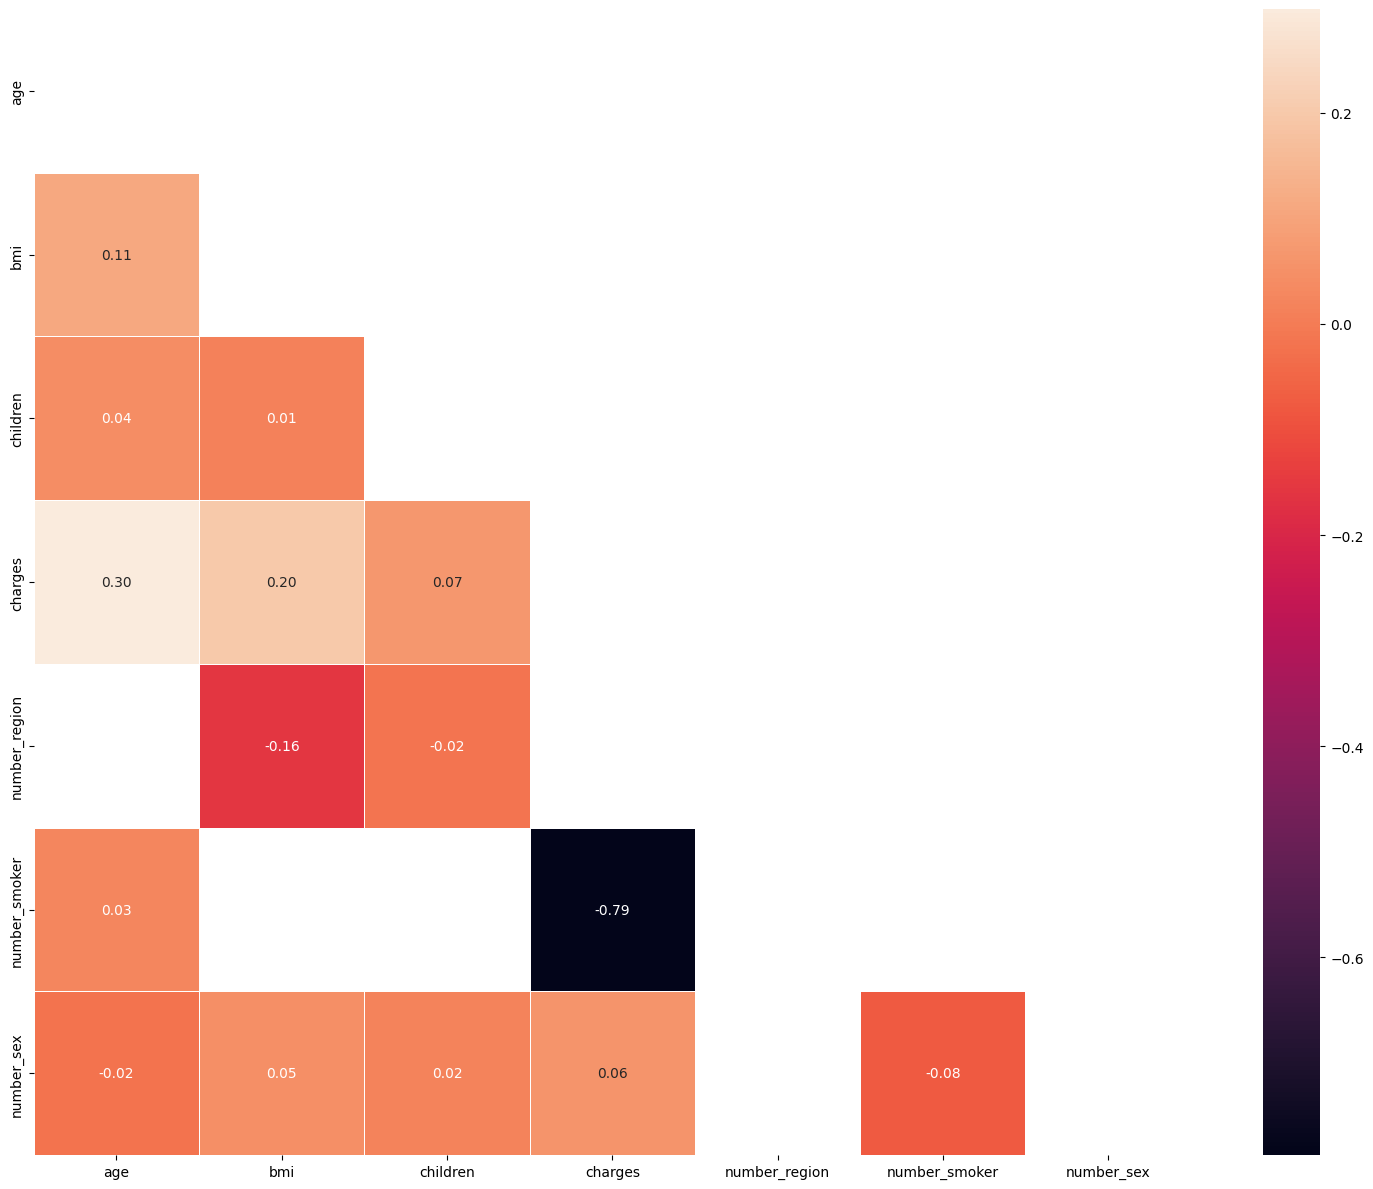

In [129]:
corr = df_numerico.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.01]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

### Observaciones: 

"Number_smoker" tiene una importante correlación con nuestra variable "Charges".

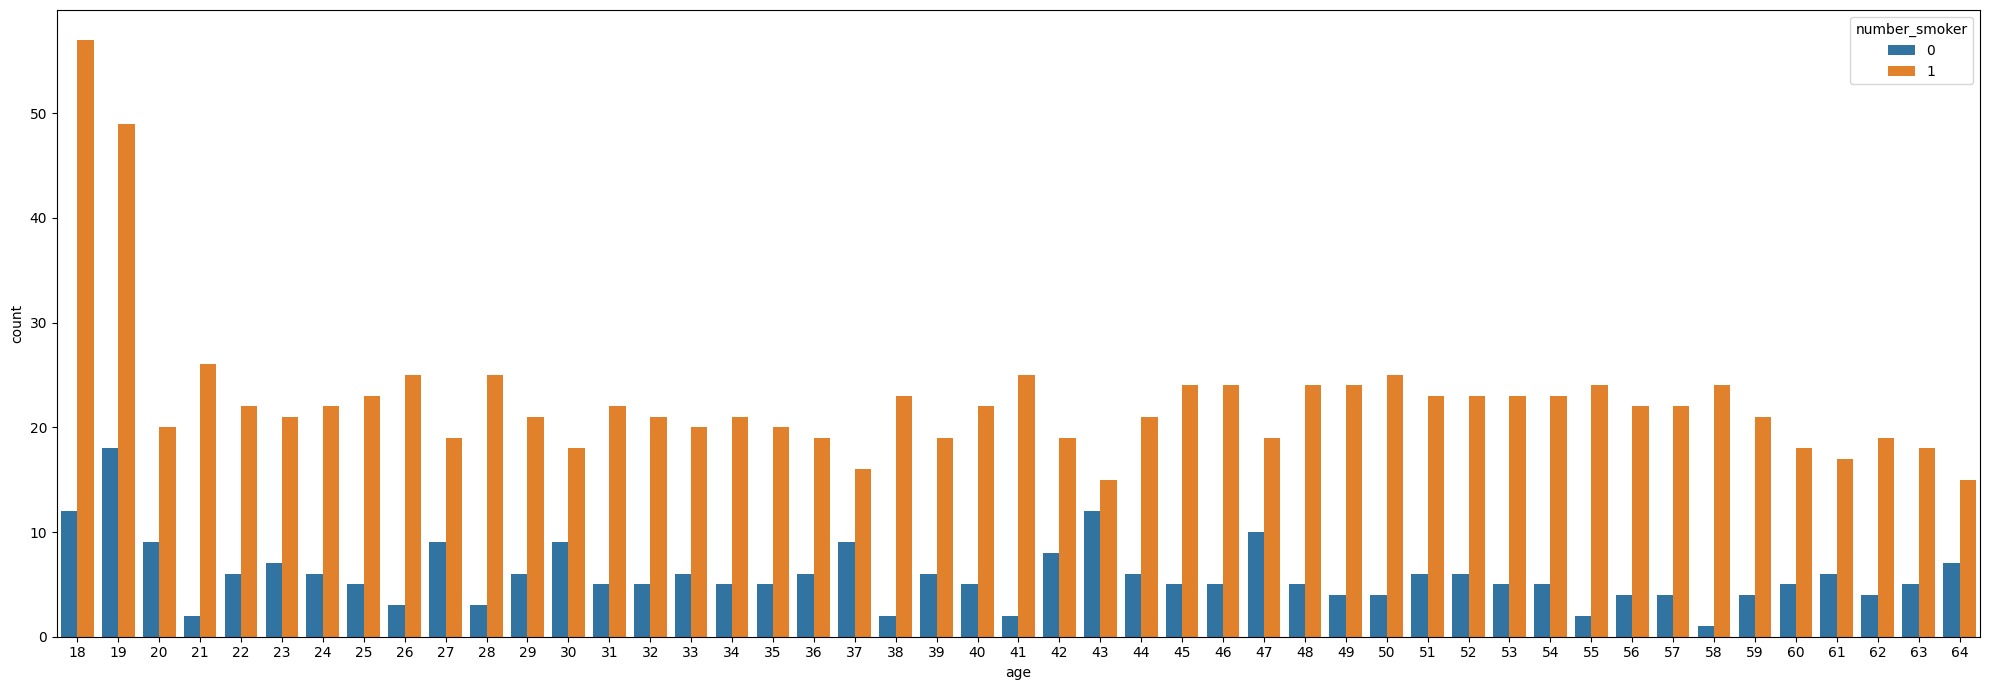

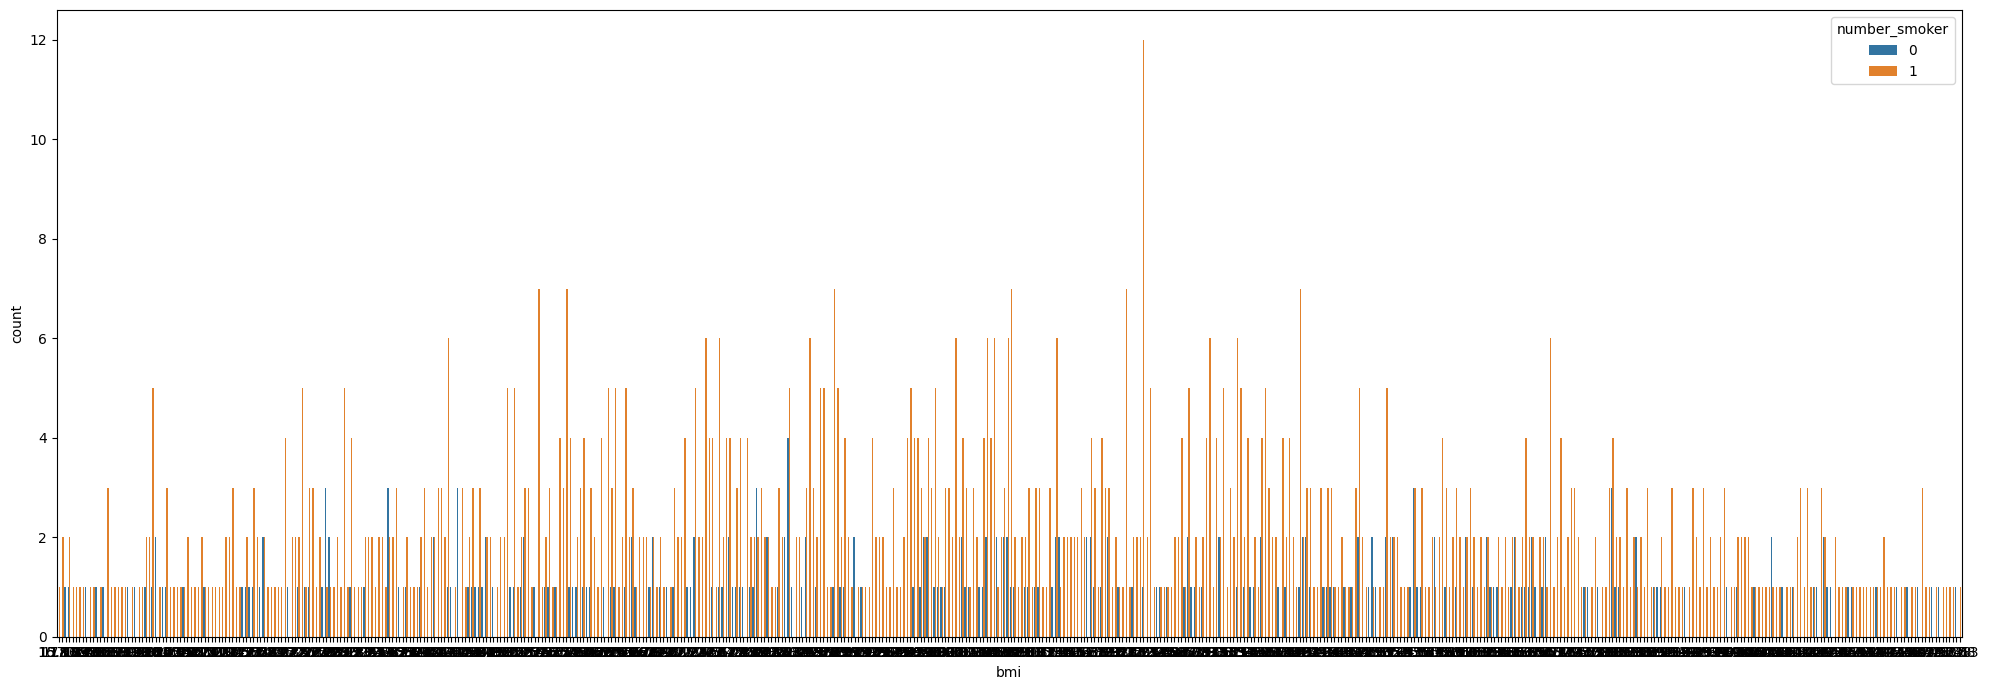

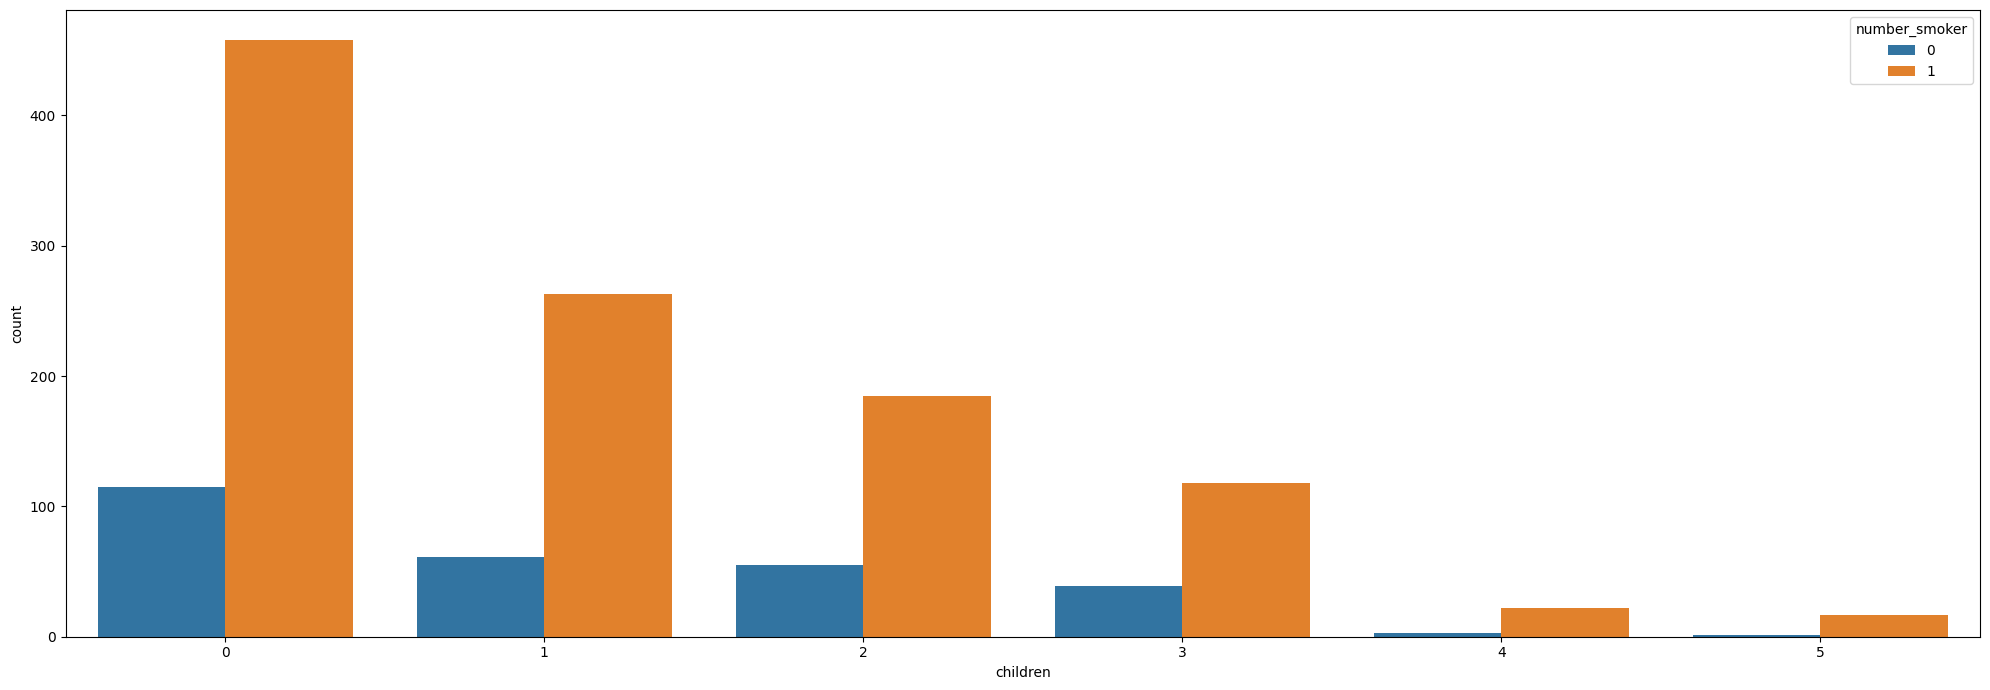

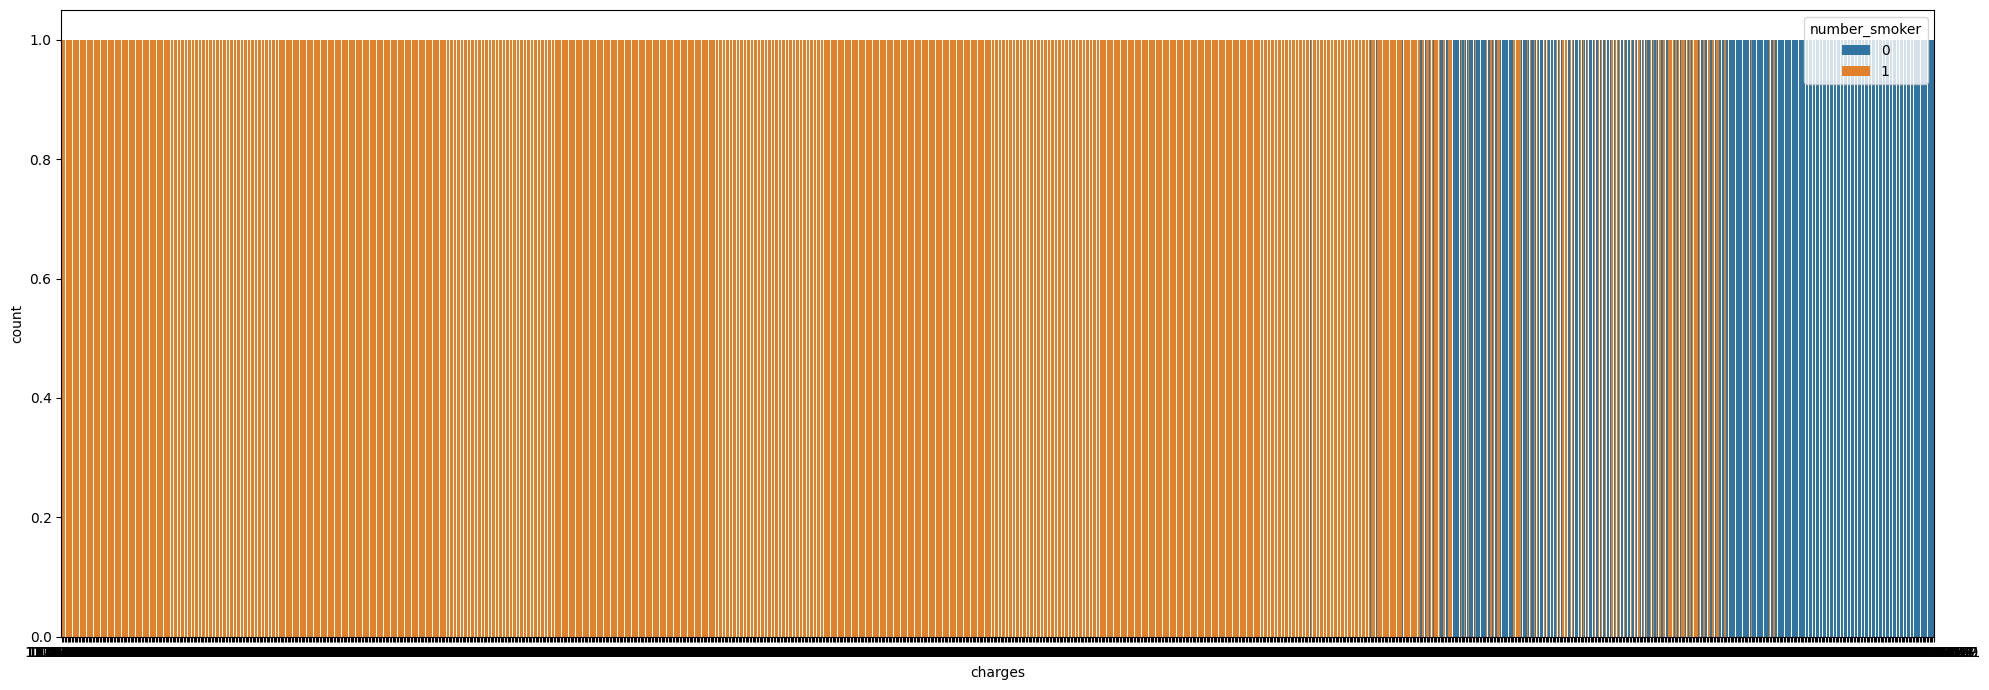

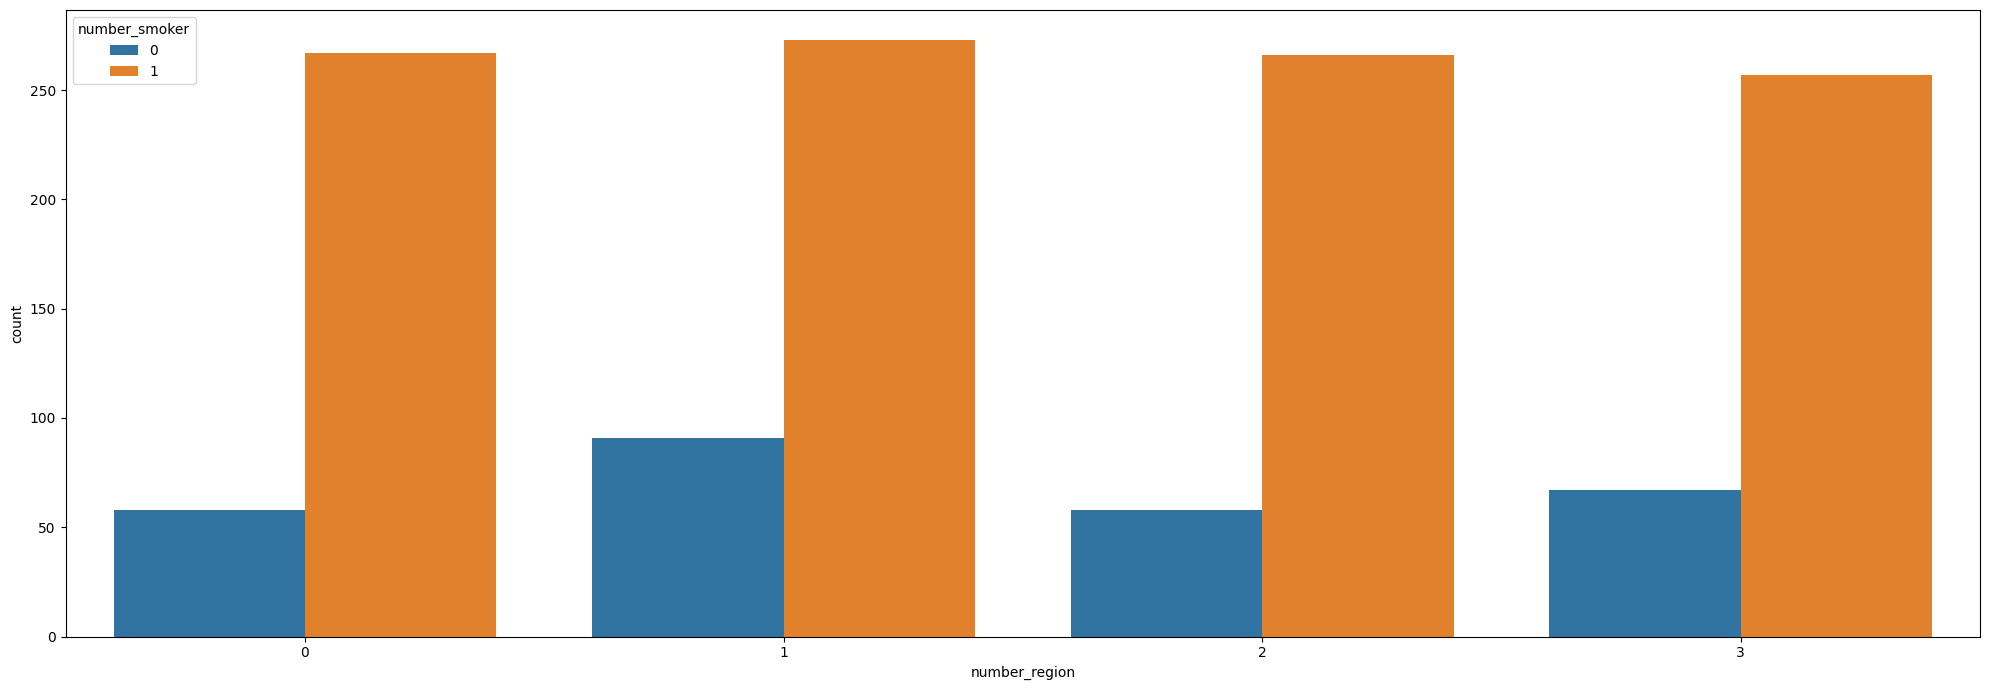

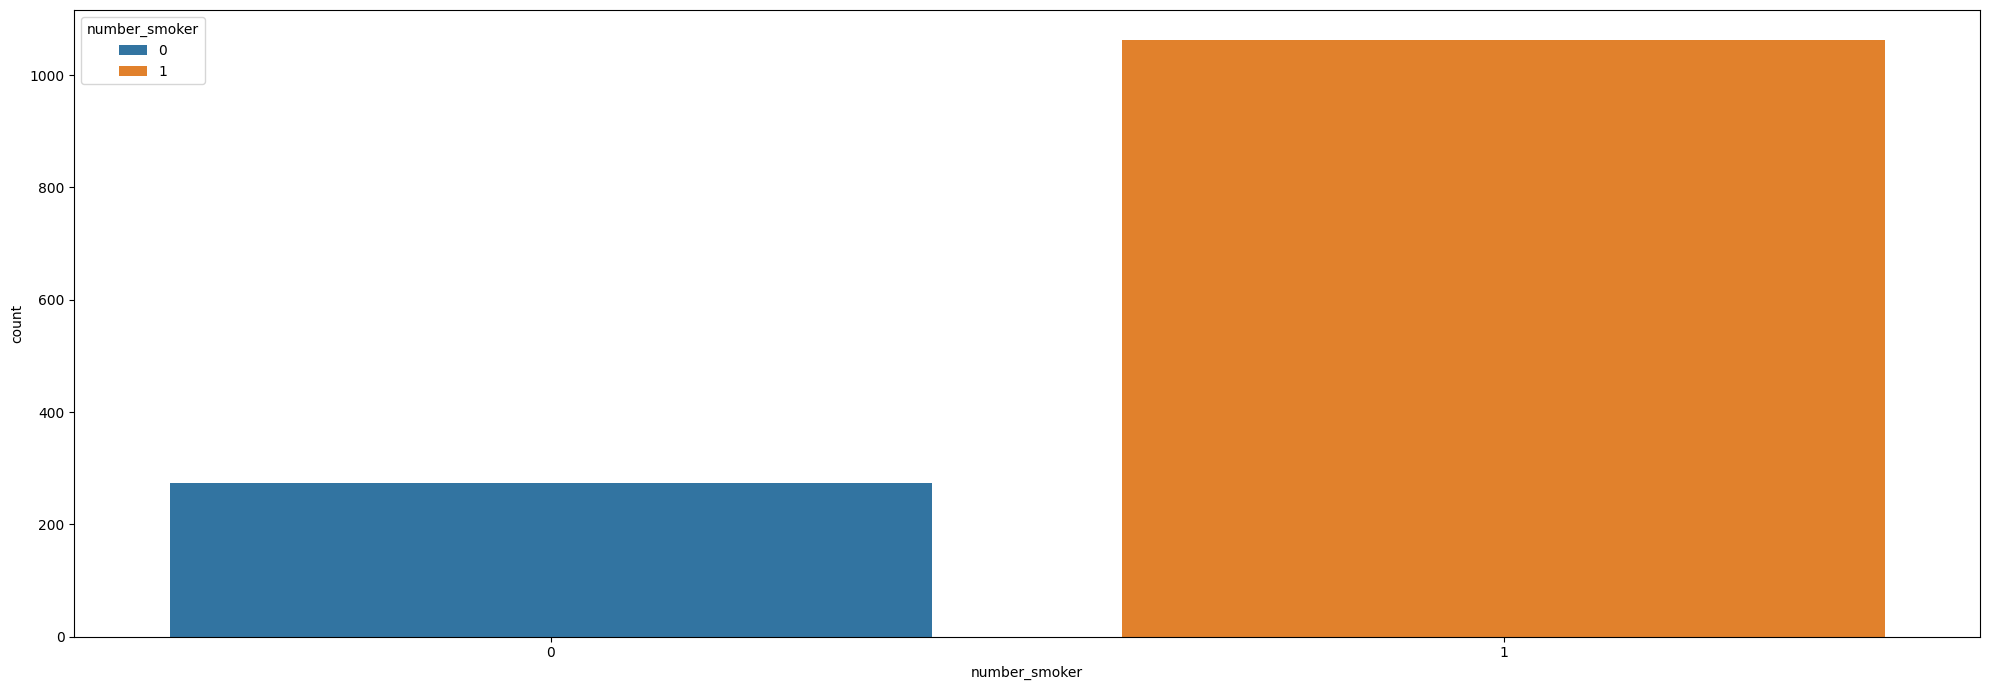

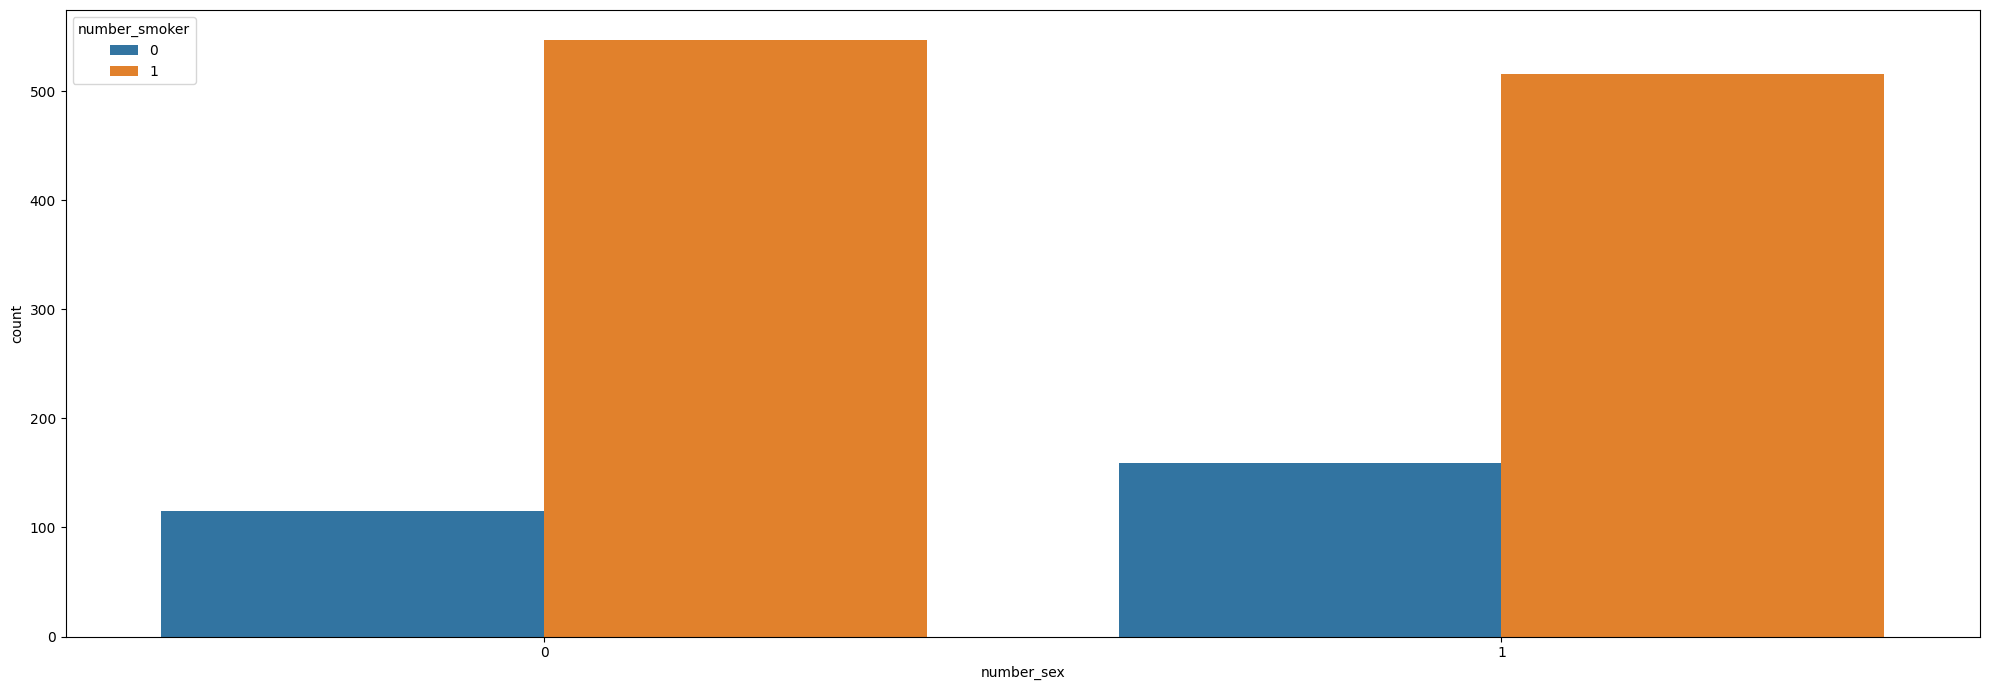

In [130]:
for columnas in df_numerico:
    fig, axis = plt.subplots(figsize=(20, 7))
    sns.countplot(data=df_numerico, x=columnas, hue='number_smoker')
    plt.tight_layout()
    plt.show()

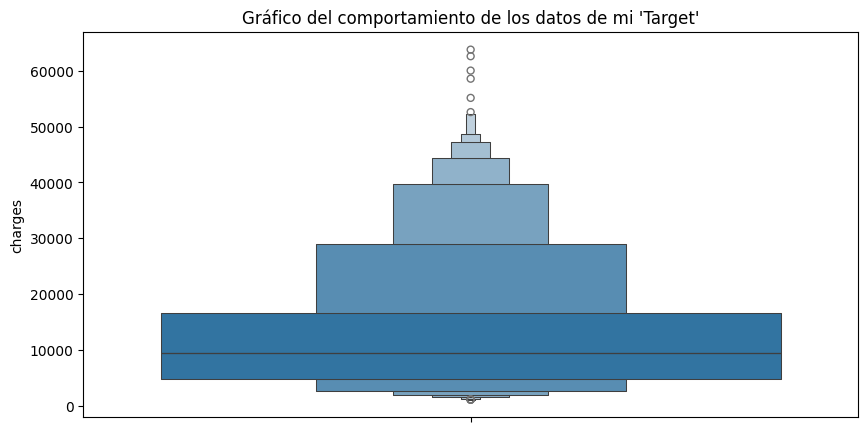

In [131]:
plt.figure(figsize=(10,5))
sns.boxenplot(data=df['charges'])
plt.title("Gráfico del comportamiento de los datos de mi 'Target'")
plt.show()

### Slipt. 

In [132]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [133]:
X_train

,age,sex,bmi,children,smoker,region
1154,48,female,27.930,4,no,northwest
1101,53,male,28.600,3,no,southwest
662,32,female,31.540,1,no,northeast
147,51,female,37.730,1,no,southeast
534,64,male,40.480,0,no,southeast
...,...,...,...,...,...,...
1199,31,female,25.800,2,no,southwest
838,35,female,23.465,2,no,northeast
1145,52,male,32.775,3,no,northwest
275,47,female,26.600,2,no,northeast


In [134]:
X_test

,age,sex,bmi,children,smoker,region
381,55,male,30.685,0,yes,northeast
38,35,male,36.670,1,yes,northeast
197,45,female,28.600,2,no,southeast
14,27,male,42.130,0,yes,southeast
94,64,female,31.300,2,yes,southwest
...,...,...,...,...,...,...
978,45,female,39.995,3,no,northeast
1109,45,male,20.350,3,no,southeast
8,37,male,29.830,2,no,northeast
809,25,male,25.840,1,no,northeast


### Encoding.

In [135]:
cat_variables = ['sex','smoker', 'region']
onehot_encoder = OneHotEncoder(sparse_output=False)

onehot_encoder.fit(X_train[cat_variables])

X_train_cat_ohe = onehot_encoder.fit_transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe, index=X_train.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe, index=X_test.index, columns=onehot_encoder.get_feature_names_out(cat_variables))


In [136]:
X_test_cat_ohe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 381 to 817
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex_female        268 non-null    float64
 1   sex_male          268 non-null    float64
 2   smoker_no         268 non-null    float64
 3   smoker_yes        268 non-null    float64
 4   region_northeast  268 non-null    float64
 5   region_northwest  268 non-null    float64
 6   region_southeast  268 non-null    float64
 7   region_southwest  268 non-null    float64
dtypes: float64(8)
memory usage: 18.8 KB


In [137]:
min_max_scaler = MinMaxScaler() 

num_variables = ['age','bmi','children']
min_max_features = min_max_scaler.fit_transform(X_train[num_variables])
min_max_features_test = min_max_scaler.transform(X_test[num_variables])
df_min_max_test = pd.DataFrame(min_max_features_test, index=X_test.index, columns=num_variables)
df_min_max_train = pd.DataFrame(min_max_features, index=X_train.index, columns=num_variables)

In [138]:
df_min_max_train

,age,bmi,children
1154,0.652174,0.306072,0.8
1101,0.760870,0.324522,0.6
662,0.304348,0.405480,0.2
147,0.717391,0.575933,0.2
534,1.000000,0.651659,0.0
...,...,...,...
1199,0.282609,0.247418,0.4
838,0.369565,0.183120,0.4
1145,0.739130,0.439488,0.6
275,0.630435,0.269448,0.4


In [139]:
df_min_max_test

,age,bmi,children
381,0.804348,0.381936,0.0
38,0.369565,0.546744,0.2
197,0.586957,0.324522,0.4
14,0.195652,0.697095,0.0
94,1.000000,0.398871,0.4
...,...,...,...
978,0.586957,0.638304,0.6
1109,0.586957,0.097343,0.6
8,0.413043,0.358392,0.4
809,0.152174,0.248520,0.2


In [140]:
X_test_cat_ohe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 381 to 817
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex_female        268 non-null    float64
 1   sex_male          268 non-null    float64
 2   smoker_no         268 non-null    float64
 3   smoker_yes        268 non-null    float64
 4   region_northeast  268 non-null    float64
 5   region_northwest  268 non-null    float64
 6   region_southeast  268 non-null    float64
 7   region_southwest  268 non-null    float64
dtypes: float64(8)
memory usage: 18.8 KB


In [141]:
columns_drop = ['sex_male', 'smoker_no']

X_train_cat_ohe.drop(columns=columns_drop, inplace=True)
X_test_cat_ohe.drop(columns=columns_drop, inplace=True)
X_train_seg = pd.concat([X_train.drop(columns=cat_variables), X_train_cat_ohe], axis=1)
X_test_seg = pd.concat([X_test.drop(columns=cat_variables), X_test_cat_ohe], axis=1)

In [142]:
X_test_seg

,age,bmi,children,sex_female,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
381,55,30.685,0,0.0,1.0,1.0,0.0,0.0,0.0
38,35,36.670,1,0.0,1.0,1.0,0.0,0.0,0.0
197,45,28.600,2,1.0,0.0,0.0,0.0,1.0,0.0
14,27,42.130,0,0.0,1.0,0.0,0.0,1.0,0.0
94,64,31.300,2,1.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
978,45,39.995,3,1.0,0.0,1.0,0.0,0.0,0.0
1109,45,20.350,3,0.0,0.0,0.0,0.0,1.0,0.0
8,37,29.830,2,0.0,0.0,1.0,0.0,0.0,0.0
809,25,25.840,1,0.0,0.0,1.0,0.0,0.0,0.0


In [143]:
X_train_final = pd.concat([X_train_seg.drop(columns=num_variables), df_min_max_train], axis=1)
X_test_final = pd.concat([X_test_seg.drop(columns=num_variables), df_min_max_test], axis=1)


In [144]:
X_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1069 entries, 1154 to 1323
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex_female        1069 non-null   float64
 1   smoker_yes        1069 non-null   float64
 2   region_northeast  1069 non-null   float64
 3   region_northwest  1069 non-null   float64
 4   region_southeast  1069 non-null   float64
 5   region_southwest  1069 non-null   float64
 6   age               1069 non-null   float64
 7   bmi               1069 non-null   float64
 8   children          1069 non-null   float64
dtypes: float64(9)
memory usage: 83.5 KB


In [145]:
X_test_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 381 to 817
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex_female        268 non-null    float64
 1   smoker_yes        268 non-null    float64
 2   region_northeast  268 non-null    float64
 3   region_northwest  268 non-null    float64
 4   region_southeast  268 non-null    float64
 5   region_southwest  268 non-null    float64
 6   age               268 non-null    float64
 7   bmi               268 non-null    float64
 8   children          268 non-null    float64
dtypes: float64(9)
memory usage: 20.9 KB


In [146]:
with open('/workspaces/Antonio27M-machine-learning/models/linear_regression-onehot-encoder.pkl', 'wb') as file:
    pickle.dump(onehot_encoder, file)

In [147]:
X_train_final

,sex_female,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,age,bmi,children
1154,1.0,0.0,0.0,1.0,0.0,0.0,0.652174,0.306072,0.8
1101,0.0,0.0,0.0,0.0,0.0,1.0,0.760870,0.324522,0.6
662,1.0,0.0,1.0,0.0,0.0,0.0,0.304348,0.405480,0.2
147,1.0,0.0,0.0,0.0,1.0,0.0,0.717391,0.575933,0.2
534,0.0,0.0,0.0,0.0,1.0,0.0,1.000000,0.651659,0.0
...,...,...,...,...,...,...,...,...,...
1199,1.0,0.0,0.0,0.0,0.0,1.0,0.282609,0.247418,0.4
838,1.0,0.0,1.0,0.0,0.0,0.0,0.369565,0.183120,0.4
1145,0.0,0.0,0.0,1.0,0.0,0.0,0.739130,0.439488,0.6
275,1.0,0.0,1.0,0.0,0.0,0.0,0.630435,0.269448,0.4


In [148]:
X_test_final

,sex_female,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,age,bmi,children
381,0.0,1.0,1.0,0.0,0.0,0.0,0.804348,0.381936,0.0
38,0.0,1.0,1.0,0.0,0.0,0.0,0.369565,0.546744,0.2
197,1.0,0.0,0.0,0.0,1.0,0.0,0.586957,0.324522,0.4
14,0.0,1.0,0.0,0.0,1.0,0.0,0.195652,0.697095,0.0
94,1.0,1.0,0.0,0.0,0.0,1.0,1.000000,0.398871,0.4
...,...,...,...,...,...,...,...,...,...
978,1.0,0.0,1.0,0.0,0.0,0.0,0.586957,0.638304,0.6
1109,0.0,0.0,0.0,0.0,1.0,0.0,0.586957,0.097343,0.6
8,0.0,0.0,1.0,0.0,0.0,0.0,0.413043,0.358392,0.4
809,0.0,0.0,1.0,0.0,0.0,0.0,0.152174,0.248520,0.2


### Modelado. 

In [149]:
model = LinearRegression()
model.fit(X_train_final, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [150]:
intercept = model.intercept_
coefficient =  model.coef_[0]

intercept, coefficient

(-2099.4683588685984, 174.6746372446263)

In [151]:
model.score(X_train_final, y_train)

0.7585289204694758

In [152]:
y_pred = model.predict(X_test_final)
y_pred

array([36892.49614029, 34168.09159298,  9195.71507812, 32210.41031587,
       39313.60683748,  4012.004917  , 28691.56499074, 37666.63632999,
       35980.45154431, 31639.16821692,  1430.53568058,  2463.38279908,
       11448.65836799, 10897.32895292, 15295.25059704, 12421.3906986 ,
       12247.45702536, 11468.33091204,  9243.16392878, 28030.57838652,
       35920.14407393,  8838.52370185,  2730.76094345, 11388.43259215,
       15629.16280272,  2278.29225451, 27580.07876686, 11011.39121096,
        5205.45134441, 26748.58674546,  8303.92012013, 12513.08998458,
       11986.10696356,  7747.45484969, 13061.90387521,  1729.89062149,
        9335.41046166, 33739.96654751, 15738.3668279 ,  3015.3908888 ,
        4471.57126257, 35477.33963578, 11411.30774358, 34321.40571715,
       25874.23775581, 32561.01416369, 24078.88785481,  5362.45417378,
       10070.42587756, 25671.77608512, 11193.24999062,  1718.44865037,
       13051.28084505,  6087.66189977,  3148.97378608, 16142.3433548 ,
      

In [153]:
len(y_test), len(y_pred)

(268, 268)

In [154]:
metrics = {'MSE': mean_squared_error(y_test, y_pred),'RMSE': root_mean_squared_error(y_test, y_pred),'MAPE': mean_absolute_percentage_error(y_test, y_pred),'R^2': r2_score(y_test, y_pred), }

metrics

{'MSE': 40923130.79713367,
 'RMSE': 6397.118945051254,
 'MAPE': 0.4276731922148429,
 'R^2': 0.7165313808459941}

### Observaciones:

>'RMSE' me dio mayor a 6000, con r2 del 71% de varianza aprox. 